# 09 — Full Model Training on Real UWHVF Data

Train GLAM end-to-end on 4,276 real patient-eyes (UWHVF).

**Architecture** (VF-functional + clinical only — no fundus images in UWHVF)
- Functional: VisualFieldEncoder (54 TD → 256) → BiLSTM-2 (512 bidirectional)
- Clinical:   5-feature MLP → 128-dim embedding
- Structural: DummyBackbone (zeros placeholder — no fundus images available)
- Fusion: Cross-attention → 512-dim
- Head: dual regression → MD rate + VFI rate + aleatoric uncertainty

**Splits**: train=2,992 / val=640 / test=644 (stratified by MD-rate quartile)

Run `uv run python scripts/train_glam.py` for full training, or execute cells below.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from src.models.backbones import VisualFieldEncoder
from src.models.temporal import BidirectionalLSTM
from src.models.fusion import AttentionFusion
from src.models.heads import ProgressionHead, GLAMModel
from src.data.loaders import GlaucomaDataset
from src.losses.progression import WeightedDualRegressionLoss
from src.utils.metrics import compute_all_metrics
from src.utils.reproducibility import set_seed

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

DEVICE    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA_DIR  = Path('../data')
CKPT_PATH = Path('../checkpoints/glam_real.pt')
CKPT_PATH.parent.mkdir(exist_ok=True)

set_seed(42)
print(f'Device: {DEVICE}')

Device: cuda


## 1. Data Loaders

In [2]:
N_VF_POINTS = 54
N_CLINICAL  = 5    # age, gender, n_visits, follow_up, md_baseline
MAX_VISITS  = 12
BATCH_SIZE  = 64

train_ds = GlaucomaDataset(DATA_DIR, split='train', n_clinical_features=N_CLINICAL, max_visits=MAX_VISITS)
val_ds   = GlaucomaDataset(DATA_DIR, split='val',   n_clinical_features=N_CLINICAL, max_visits=MAX_VISITS)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, drop_last=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train: {len(train_ds):,} | Val: {len(val_ds):,}')
batch = next(iter(train_dl))
print(f'vf_series: {tuple(batch["vf_series"].shape)}')
print(f'clinical:  {tuple(batch["clinical"].shape)}')
print(f'md_rate range: [{batch["md_rate"].min():.3f}, {batch["md_rate"].max():.3f}]')

Train: 2,992 | Val: 640


vf_series: (64, 12, 54)
clinical:  (64, 5)
md_rate range: [-2.064, 1.589]


## 2. Build Model

In [3]:
STRUCT_DIM = 64    # Placeholder — images are zeros (no fundus in UWHVF)
CLIN_DIM   = 128
FUSION_DIM = 512

class DummyBackbone(nn.Module):
    """Zeros placeholder for structural branch (no fundus images in UWHVF)."""
    def __init__(self, out_dim=64):
        super().__init__()
        self.out_dim = out_dim
        self.proj = nn.Linear(3 * 224 * 224, out_dim)  # never called
    def forward(self, x):
        return torch.zeros(x.size(0), self.out_dim, device=x.device)

backbone  = DummyBackbone(STRUCT_DIM)
vf_enc    = VisualFieldEncoder(n_points=N_VF_POINTS, hidden_dim=256)
temporal  = BidirectionalLSTM(input_dim=256, hidden_dim=256, num_layers=2, dropout=0.3)
fusion    = AttentionFusion(structural_dim=STRUCT_DIM, functional_dim=temporal.out_dim,
                            clinical_dim=CLIN_DIM, fused_dim=FUSION_DIM)
clin_emb  = nn.Sequential(
    nn.Linear(N_CLINICAL, 64), nn.LayerNorm(64),  nn.GELU(),
    nn.Linear(64, CLIN_DIM),  nn.LayerNorm(CLIN_DIM), nn.GELU(),
)
head  = ProgressionHead(input_dim=FUSION_DIM, dropout=0.3)
model = GLAMModel(backbone, vf_enc, temporal, fusion, clin_emb, head).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {n_params:,}')

with torch.no_grad():
    out = model(batch['image'].to(DEVICE), batch['vf_series'].to(DEVICE),
                batch['clinical'].to(DEVICE), batch['vf_length'].to(DEVICE))
print(f'Forward pass OK — md_pred: {out["md_pred"].shape}')

Trainable parameters: 13,605,319


Forward pass OK — md_pred: torch.Size([64, 1])


## 3. Training (or load existing checkpoint)

In [4]:
if CKPT_PATH.exists():
    ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model_state'])
    print(f'Loaded checkpoint: epoch={ckpt["epoch"]}, val_loss={ckpt["val_loss"]:.4f}')
    print(f'Val MD MAE (best): {ckpt["val_md_mae"]:.4f} dB/yr')
    print('To retrain, delete checkpoints/glam_real.pt and re-run.')
    print('Or run: uv run python scripts/train_glam.py')
else:
    print('No checkpoint found. Running training...')
    import subprocess
    subprocess.run(['uv', 'run', 'python', 'scripts/train_glam.py'], cwd='..')
    ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model_state'])

Loaded checkpoint: epoch=29, val_loss=0.1503
Val MD MAE (best): 0.1527 dB/yr
To retrain, delete checkpoints/glam_real.pt and re-run.
Or run: uv run python scripts/train_glam.py


## 4. Training Curves (from saved history)

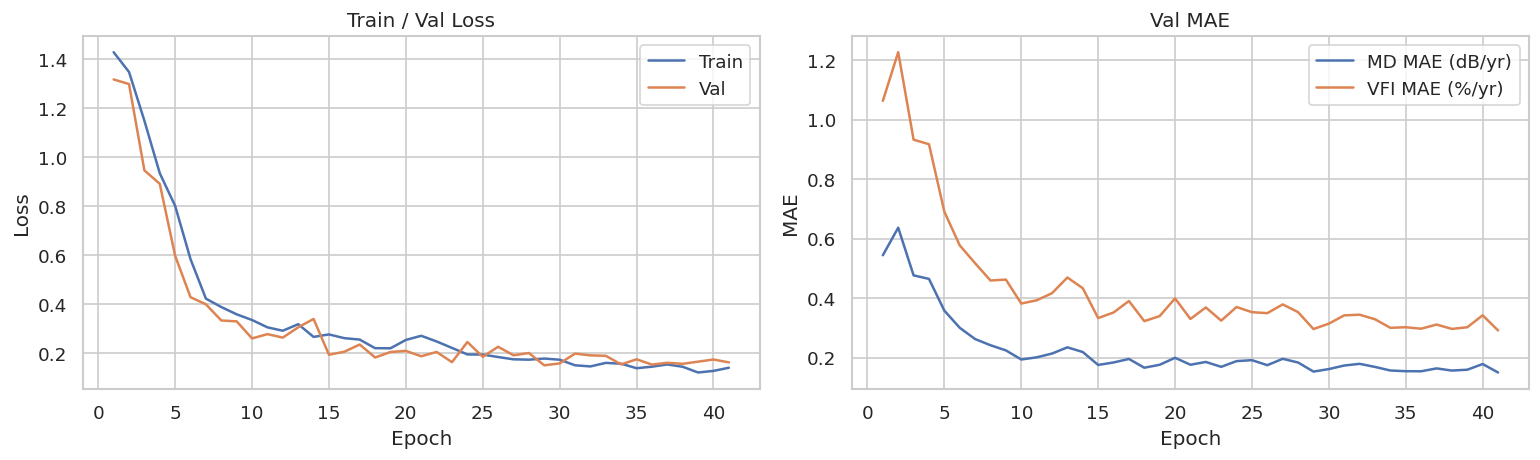

Best val MD MAE: 0.1497 dB/yr at epoch 41


In [5]:
import json
hist_path = Path('../checkpoints/training_history.json')
if hist_path.exists():
    h = json.load(open(hist_path))
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    e = range(1, len(h['tl']) + 1)
    axes[0].plot(e, h['tl'], label='Train'); axes[0].plot(e, h['vl'], label='Val')
    axes[0].set(xlabel='Epoch', ylabel='Loss', title='Train / Val Loss'); axes[0].legend()
    axes[1].plot(e, h['md_mae'], label='MD MAE (dB/yr)')
    axes[1].plot(e, h['vfi_mae'], label='VFI MAE (%/yr)')
    axes[1].set(xlabel='Epoch', ylabel='MAE', title='Val MAE'); axes[1].legend()
    plt.tight_layout()
    plt.savefig('../reports/09_training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Best val MD MAE: {min(h["md_mae"]):.4f} dB/yr at epoch {h["md_mae"].index(min(h["md_mae"]))+1}')
else:
    print('No history file found.')

## 5. Val Set Metrics (best checkpoint)

In [6]:
model.eval()
mp, mt, vp, vt = [], [], [], []
with torch.no_grad():
    for b in val_dl:
        out = model(b['image'].to(DEVICE), b['vf_series'].to(DEVICE),
                    b['clinical'].to(DEVICE), b['vf_length'].to(DEVICE))
        mp.append(out['md_pred'].squeeze().cpu().numpy()); mt.append(b['md_rate'].numpy())
        vp.append(out['vfi_pred'].squeeze().cpu().numpy()); vt.append(b['vfi_rate'].numpy())

metrics = compute_all_metrics(np.concatenate(mp), np.concatenate(mt),
                              np.concatenate(vp), np.concatenate(vt))
print('=== VAL SET (best checkpoint) ===')
for k,v in metrics.items():
    if isinstance(v, float):
        print(f'  {k:<40}: {v:.4f}')
print('\n→ Next: 10_evaluation.ipynb for test-set evaluation')

=== VAL SET (best checkpoint) ===
  md_mae                                  : 0.1527
  md_rmse                                 : 0.2756
  md_r2                                   : 0.9149
  md_bias                                 : 0.0082
  vfi_mae                                 : 0.2957
  vfi_rmse                                : 0.5288
  vfi_r2                                  : 0.9201
  vfi_bias                                : 0.0176
  fast_progressor_sensitivity             : 0.8387
  fast_progressor_specificity             : 0.9948
  fast_progressor_ppv                     : 0.9455
  within_half_db_pct                      : 0.9359

→ Next: 10_evaluation.ipynb for test-set evaluation
